# Loading libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Loading data

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
df

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,1/1/2024,Phone,7,37300,CUST001,East,261100
1,1/2/2024,Headphones,4,15406,CUST002,North,61624
2,1/3/2024,Phone,2,21746,CUST003,West,43492
3,1/4/2024,Headphones,1,30895,CUST004,East,30895
4,1/5/2024,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,4/5/2024,Tablet,8,20770,CUST096,North,166160
96,4/6/2024,Headphones,1,7647,CUST097,West,7647
97,4/7/2024,Tablet,5,27196,CUST098,East,135980
98,4/8/2024,Monitor,1,30717,CUST099,North,30717


# Descriptive Statistics

## First moment business decision

In [4]:
for col in df.select_dtypes(include="number").columns:
    print(f"Mean of {col}: {df[col].mean()}")
    print(f"Median of {col}: {df[col].median()}")
    print(f"Mode of {col}: {df[col].mode()[0]}")

Mean of Quantity: 4.78
Median of Quantity: 5.0
Mode of Quantity: 4
Mean of Price: 25808.51
Median of Price: 24192.0
Mode of Price: 1308
Mean of Total_Sales: 123650.48
Median of Total_Sales: 97955.5
Mode of Total_Sales: 6540


## Second moment business decision

In [5]:
for col in df.select_dtypes(include="number").columns:
    print(f"Standard Deviation of {col}: {df[col].std()}")
    print(f"Variance of {col}: {df[col].var()}")
    print(f"Range of {col}: {df[col].max() - df[col].min()}")

Standard Deviation of Quantity: 2.588162641447763
Variance of Quantity: 6.698585858585861
Range of Quantity: 8
Standard Deviation of Price: 13917.630241724111
Variance of Price: 193700431.54535356
Range of Price: 48622
Standard Deviation of Total_Sales: 100161.08527499213
Variance of Total_Sales: 10032243003.464245
Range of Total_Sales: 367392


# Data Distribution

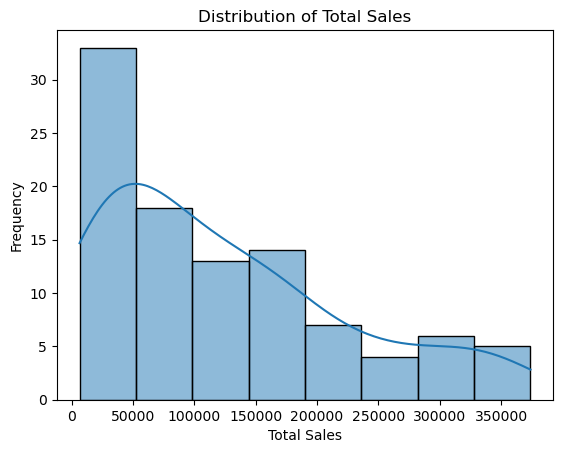

In [6]:
sns.histplot(df['Total_Sales'], kde=True)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

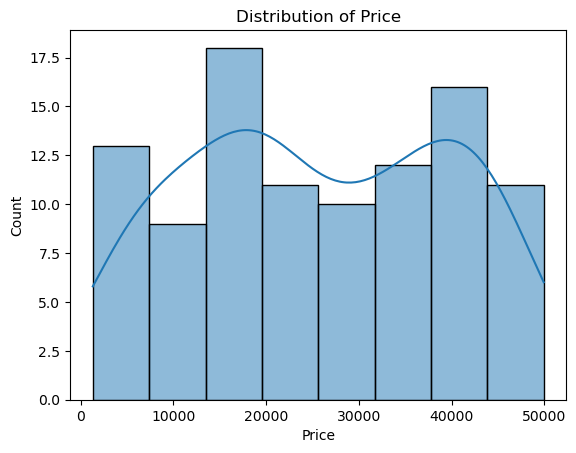

In [7]:
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.show()

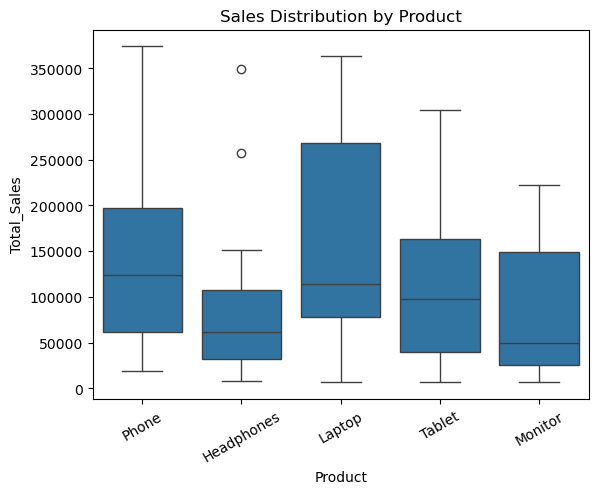

In [8]:
sns.boxplot(x='Product', y='Total_Sales', data=df)
plt.title("Sales Distribution by Product")
plt.xticks(rotation=30)
plt.show()

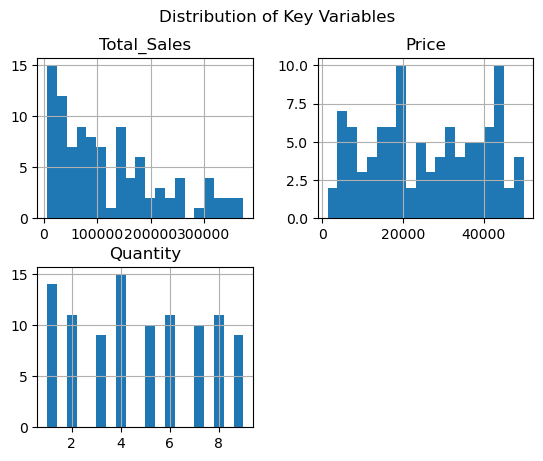

In [9]:
df[['Total_Sales', 'Price', 'Quantity']].hist(bins=20)
plt.suptitle("Distribution of Key Variables")
plt.show()

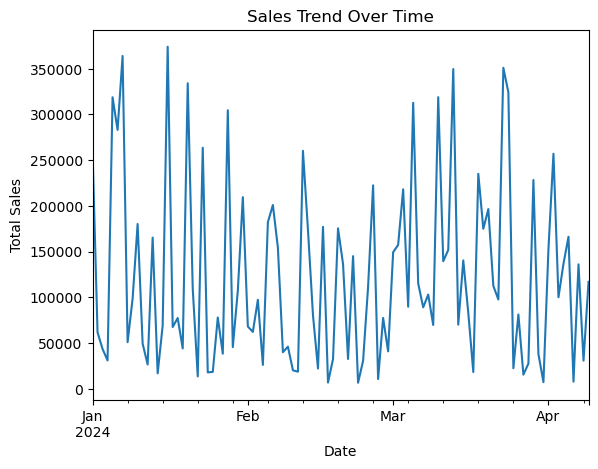

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

daily_sales = df.groupby('Date')['Total_Sales'].sum()

daily_sales.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

## Sales by Product

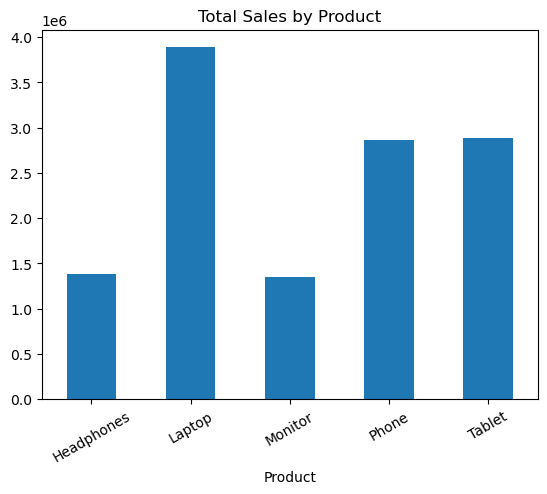

In [11]:
product_sales = df.groupby('Product')['Total_Sales'].sum()

product_sales.plot(kind='bar')
plt.title("Total Sales by Product")
plt.xticks(rotation=30)
plt.show()

## Sales by Region

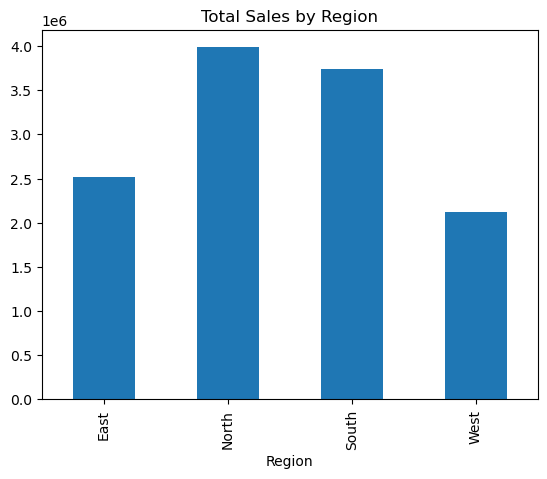

In [12]:
region_sales = df.groupby('Region')['Total_Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Total Sales by Region")
plt.show()

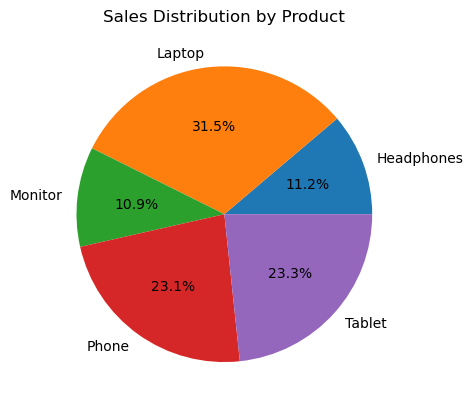

In [13]:
product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Product")
plt.ylabel("")
plt.show()

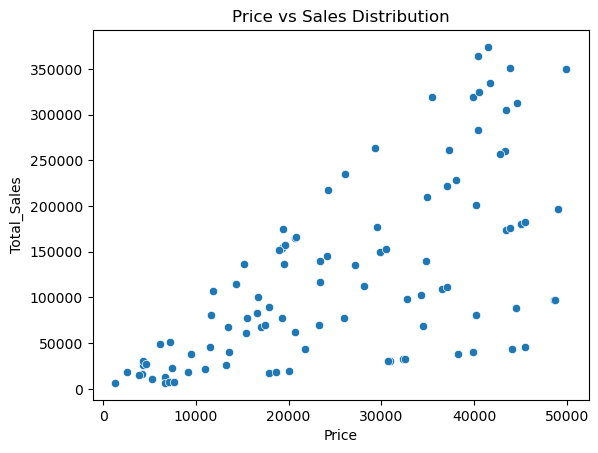

In [14]:
sns.scatterplot(x='Price', y='Total_Sales', data=df)
plt.title("Price vs Sales Distribution")
plt.show()

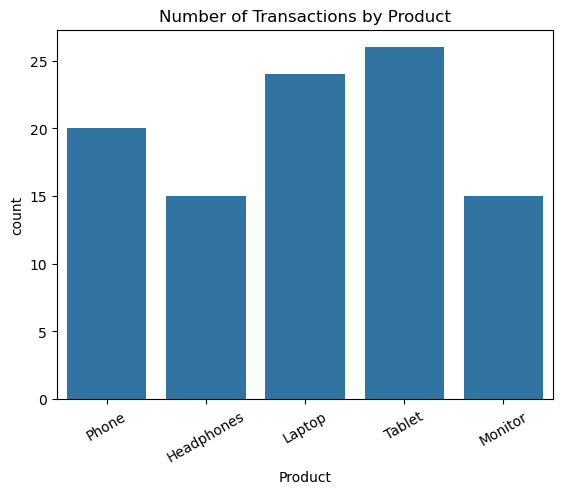

In [15]:
sns.countplot(x='Product', data=df)
plt.title("Number of Transactions by Product")
plt.xticks(rotation=30)
plt.show()

In [16]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Price'], df['Total_Sales'])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.6461309528798176
p-value: 3.8821632176369057e-13


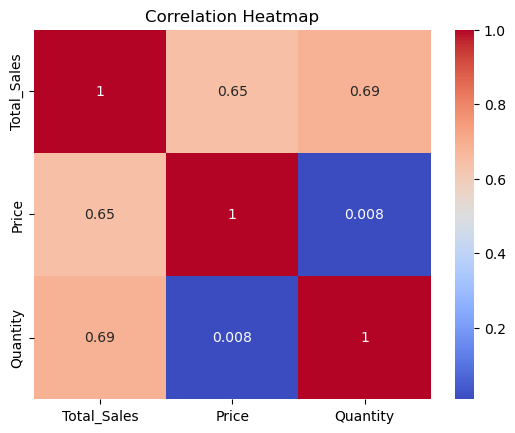

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['Total_Sales','Price','Quantity']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pearson Correlation

In [18]:
corr, p_value = pearsonr(df['Quantity'], df['Total_Sales'])

print("Correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Quantity significantly affects Total Sales")
else:
    print("Fail to reject H0")

Correlation: 0.6881074758580694
p-value: 2.580513799627829e-15
Reject H0 → Quantity significantly affects Total Sales


# T-test

In [19]:
from scipy.stats import ttest_ind

products = df['Product'].unique()

group1 = df[df['Product'] == products[0]]['Total_Sales']
group2 = df[df['Product'] == products[1]]['Total_Sales']

t_stat, p_value = ttest_ind(group1, group2)

print("T-stat:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Significant difference between products")
else:
    print("Fail to reject H0")

T-stat: 1.4458632852193465
p-value: 0.15764668764988843
Fail to reject H0


# ANOVA

In [20]:
from scipy.stats import f_oneway

groups = [group['Total_Sales'].values for name, group in df.groupby('Product')]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → At least one product differs")
else:
    print("Fail to reject H0")

F-stat: 2.0507910094792132
p-value: 0.09342819607538903
Fail to reject H0


# Confidence Interval

In [21]:
import numpy as np
import scipy.stats as stats

# Sample data
data = df['Total_Sales']

# Step 1: Mean
mean = np.mean(data)

# Step 2: Standard Error
sem = stats.sem(data)

# Step 3: Confidence Interval (95%)
confidence = 0.95
n = len(data)

ci_low, ci_high = stats.t.interval(confidence, df=n-1, loc=mean, scale=sem)

# Step 4: Margin of Error
margin_of_error = ci_high - mean

print("Mean:", mean)
print("95% Confidence Interval:", (ci_low, ci_high))
print("Margin of Error:", margin_of_error)

Mean: 123650.48
95% Confidence Interval: (np.float64(103776.34767158539), np.float64(143524.6123284146))
Margin of Error: 19874.132328414606


# Linear Regression

# For Quantity

### Initiating Baseline of code

In [22]:
import statsmodels.api as sm

# Independent variable (X) and Dependent variable (y)
X = df['Quantity']
y = df['Total_Sales']

# Add intercept (constant)
X = sm.add_constant(X)

# Build model
model_quantity = sm.OLS(y, X).fit()

# Summary
print(model_quantity.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     88.13
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.58e-15
Time:                        23:24:55   Log-Likelihood:                -1260.8
No. Observations:                 100   AIC:                             2526.
Df Residuals:                      98   BIC:                             2531.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3638.7415   1.54e+04     -0.236      0.8

## R-squared

In [23]:
# R-squared for your regression model
r_squared = model_quantity.rsquared
print("R-squared:", r_squared)

R-squared: 0.47349189833176375


## Price

### Initiating baseline code

In [ ]:
X2 = sm.add_constant(df['Price'])
model_price = sm.OLS(df['Total_Sales'], X2).fit()
print(model_price.summary())

### R-squared

In [ ]:
# R-squared for your regression model
r_squared = model_price.rsquared
print("R-squared:", r_squared)

## Combined

### Initiating baseline code

In [24]:
X3 = df[['Quantity', 'Price']]
X3 = sm.add_constant(X3)

model_combined = sm.OLS(df['Total_Sales'], X3).fit()
print(model_combined.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           4.40e-46
Time:                        23:27:25   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.217e+05   9668.294    -12.586      0.0

### R-squared

In [25]:
# R-squared for your regression model
r_squared = model_combined.rsquared
print("R-squared:", r_squared)

R-squared: 0.8839073148081258
